##Principal component analysis PCA

## Example

We will use (sorry) the classical `iris` dataset.

The Iris flower data set is a multivariate data set introduced by the British statistician and biologist Ronald Fisher in his 1936 paper The use of multiple measurements in taxonomic problems. It is sometimes called Anderson's Iris data set because Edgar Anderson collected the data to quantify the morphologic variation of Iris flowers of three related species. The data set consists of 50 samples from each of three species of Iris (Iris Setosa, Iris virginica, and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

![](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png)



The dataset contains a set of 150 records under 5 attributes

* Petal Length
* Petal Width
* Sepal Length
* Sepal width
* Class(Species)

This dataset became a typical test case for many statistical techniques in machine learning such as clasification, clustering, and dimensionality reduction.

In [ ]:
import pandas as pd #Pandas handles tabular data
pd.set_option('display.float_format', lambda x: '%.3f' % x) # turn off scientific notation and too much decimal blah
import matplotlib.pyplot as plt # standard plotting library
import numpy as np #Numpy for linear algebra & co
import seaborn as sns # For pretty dataviz
sns.set_style("darkgrid") # Define style for dataviz

### Load the data

In [ ]:
# load dataset into Pandas DataFrame
data = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
                 names=['sepal length','sepal width','petal length','petal width','species'])

### Brief exploration

In the following, we will do some of the standard inspections one should do with every new dataset to get a feeling for its påroperties.

In [3]:
# Check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  150 non-null    float64
 1   sepal width   150 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# Print the first 5 rows
data.head()

,sepal length,sepal width,petal length,petal width,species
0,5.100,3.500,1.400,0.200,Iris-setosa
1,4.900,3.000,1.400,0.200,Iris-setosa
2,4.700,3.200,1.300,0.200,Iris-setosa
3,4.600,3.100,1.500,0.200,Iris-setosa
4,5.000,3.600,1.400,0.200,Iris-setosa


In [5]:
# Descriptive statistics
data.describe()


,sepal length,sepal width,petal length,petal width
count,150.000,150.000,150.000,150.000
mean,5.843,3.054,3.759,1.199
std,0.828,0.434,1.764,0.763
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


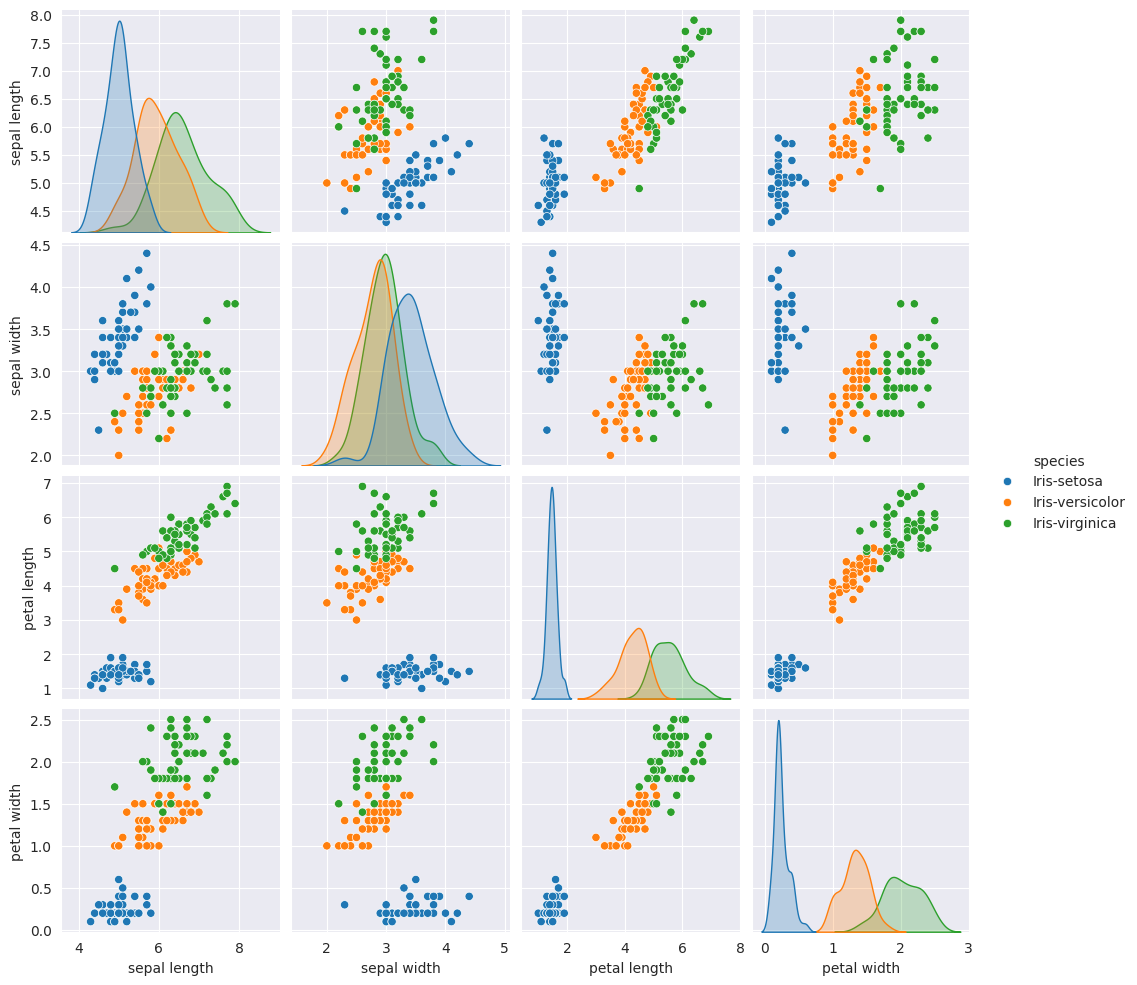

In [6]:
# Here, one of my very favorite visualizations... save that one.
# Sns pairplot provides a matrix with scatters on the triangles, and the distribution on the diagonal
sns.pairplot(data, hue='species')

In [7]:
# other plots tht can be
#histograms
#paralel coordinates plot
#boxplots/violonplots for distributions

<Axes: >

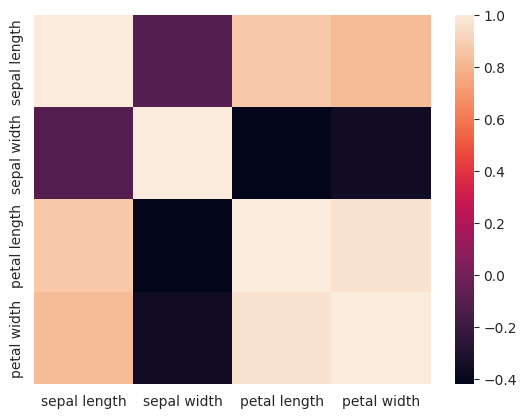

In [8]:
# And lastly, a correlation plot
data_num = data[["sepal length",	"sepal width",	"petal length",	"petal width"]]
sns.heatmap(data_num.corr())

### Preprocessing

Since in PCA exercises the features used can be of different scale (eg. meter & kilometer) or dispolay a very different variance, it is common practice in ML workflow to normalize features. By doing so, we prevent features with high variance or scale ranges to dominate.

We here apply a standard scaler, where we substract for every feature its mean, and thyen divide by its standard deviation.

$$StandardScale() = {\frac {X-\mu }{\sigma }}$$

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
# Let's standard-scale our data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_num)

In [11]:
# What are mean and Sd now?
pd.DataFrame(data_scaled, columns=data_num.columns).describe()

,sepal length,sepal width,petal length,petal width
count,150.000,150.000,150.000,150.000
mean,-0.000,-0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003
min,-1.870,-2.439,-1.569,-1.444
25%,-0.901,-0.588,-1.228,-1.182
50%,-0.053,-0.125,0.336,0.133
75%,0.675,0.569,0.763,0.791
max,2.492,3.115,1.786,1.711


### Executing PCA

In [12]:
# Instantiate a PCA object
from sklearn.decomposition import PCA # PCA from  sklearn, the python ML standard library
model = PCA() # Number of components needs to be defined. We just for illustration take about half of the numbers of features

In [13]:
# Fit the model
model.fit(data_scaled)

PCA()

In [14]:
# Fit and transform the data
data_reduced = model.transform(data_scaled)
print(data_reduced)

[[-2.26454173e+00  5.05703903e-01  1.21943348e-01 -2.30733235e-02]
 [-2.08642550e+00 -6.55404729e-01  2.27250832e-01 -1.03208244e-01]
 [-2.36795045e+00 -3.18477311e-01 -5.14796236e-02 -2.78252250e-02]
 [-2.30419716e+00 -5.75367713e-01 -9.88604444e-02  6.63114622e-02]
 [-2.38877749e+00  6.74767397e-01 -2.14278490e-02  3.73972870e-02]
 [-2.07053681e+00  1.51854856e+00 -3.06842583e-02 -4.39877494e-03]
 [-2.44571134e+00  7.45626750e-02 -3.42197636e-01  3.80965668e-02]
 [-2.23384186e+00  2.47613932e-01  8.25744645e-02  2.55051623e-02]
 [-2.34195768e+00 -1.09514636e+00 -1.53562399e-01  2.67938291e-02]
 [-2.18867576e+00 -4.48629048e-01  2.46559522e-01  3.99073035e-02]
 [-2.16348656e+00  1.07059558e+00  2.64009373e-01 -1.53011377e-02]
 [-2.32737775e+00  1.58587455e-01 -1.00165616e-01  1.34554258e-01]
 [-2.22408272e+00 -7.09118158e-01  2.23214514e-01 -2.63061382e-03]
 [-2.63971626e+00 -9.38281982e-01 -1.89570030e-01  1.94220183e-02]
 [-2.19229151e+00  1.88997851e+00  4.69480095e-01 -1.92782042e

### Inspecting Results

<Axes: xlabel='None'>

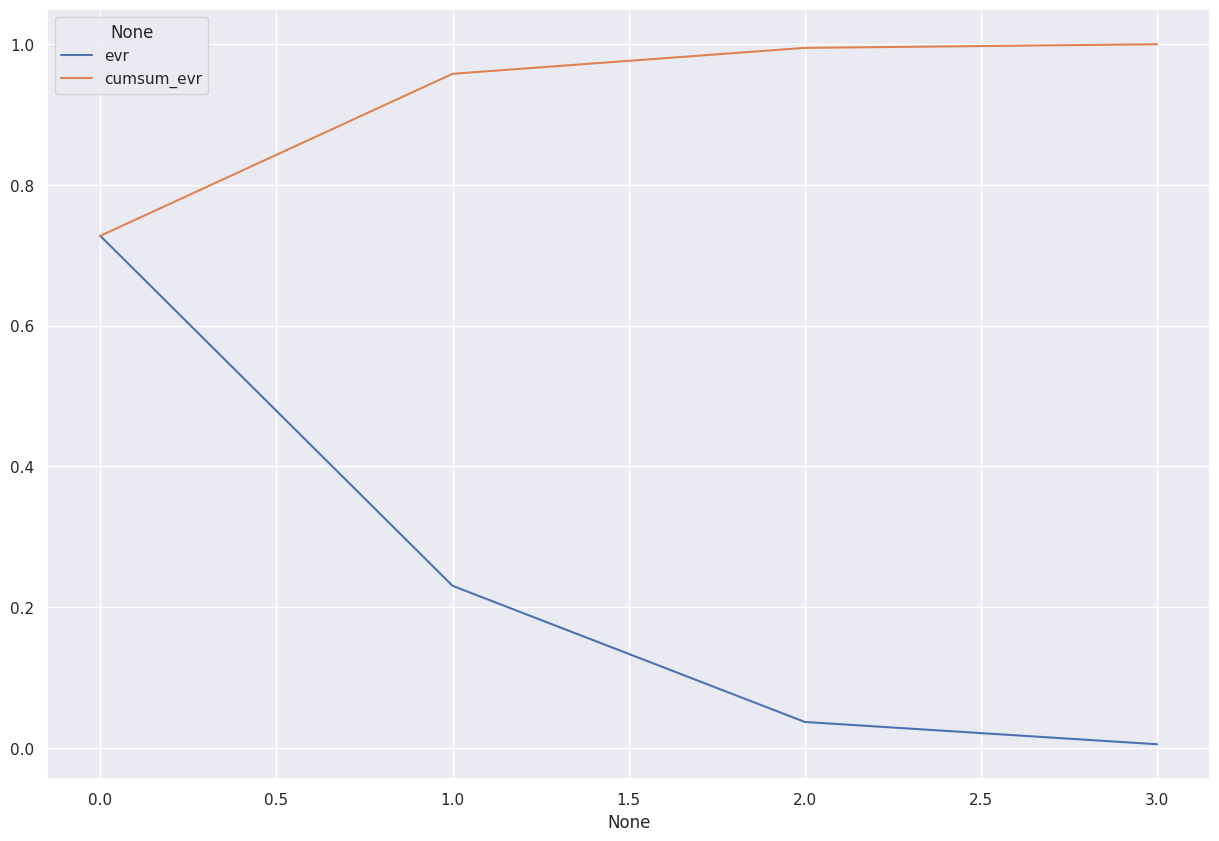

In [15]:
plot_data = pd.DataFrame({'evr': model.explained_variance_ratio_, 'cumsum_evr': np.cumsum(model.explained_variance_ratio_)}).stack()
sns.set(rc={'figure.figsize':(15,10)})
sns.lineplot(y = plot_data.values, x = plot_data.index.get_level_values(0), hue=plot_data.index.get_level_values(1))

In [16]:
print(model.explained_variance_ratio_)

[0.72770452 0.23030523 0.03683832 0.00515193]


PLOTTING ALL THE PCS

In [17]:
def myplot(score,coeff,labels=None):
    plot_df = pd.DataFrame(score[:, 0:2], columns=['PC1', 'PC2'])
    plot_df['species'] = data['species'].values

    # Scale factors for visual clarity
    scalex = 1.0 / (plot_df['PC1'].max() - plot_df['PC1'].min())
    scaley = 1.0 / (plot_df['PC2'].max() - plot_df['PC2'].min())

    # Plot the scatter using seaborn
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='species', palette='deep', s=60, edgecolor='k', alpha=0.8)

    # Plot arrows representing variable loadings
    n = coeff.shape[0]
    arrow_scale = 3  # adjust this to make arrows longer
    for i in range(n):
        plt.arrow(
            0, 0,
            arrow_scale * coeff[i, 0],
            arrow_scale * coeff[i, 1],
            color='red',
            alpha=0.6,
            head_width=0.05,
            head_length=0.07,
            linewidth=1.5
        )
        label = data.columns[i] if labels is None else labels[i]
        plt.text(
            arrow_scale * coeff[i, 0] * 1.1,
            arrow_scale * coeff[i, 1] * 1.1,
            label,
            color='black',
            ha='center',
            va='center'
        )

    # Aesthetic adjustments
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Biplot")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



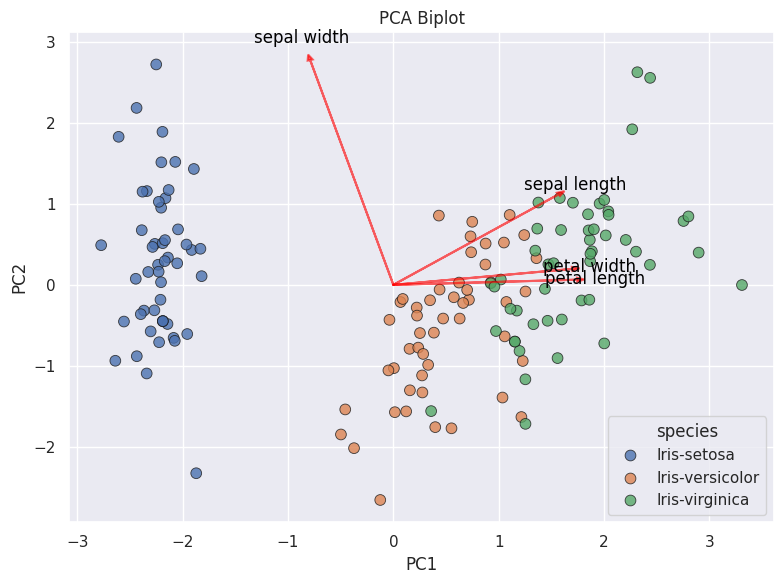

In [18]:
#Call the function. Use only the 2 PCs.
myplot(data_reduced[:,0:2],np.transpose(model.components_[0:2, :]))
plt.show()


The important features are the ones that influence more the components and thus, have a large absolute value/score on the component.

In [19]:
pcscores = pd.DataFrame(data_reduced)
loadings = pd.DataFrame(model.components_, columns=data_num.columns)
loadings.index = ['PC'+str(i+1) for i in range(len(pcscores.columns))]

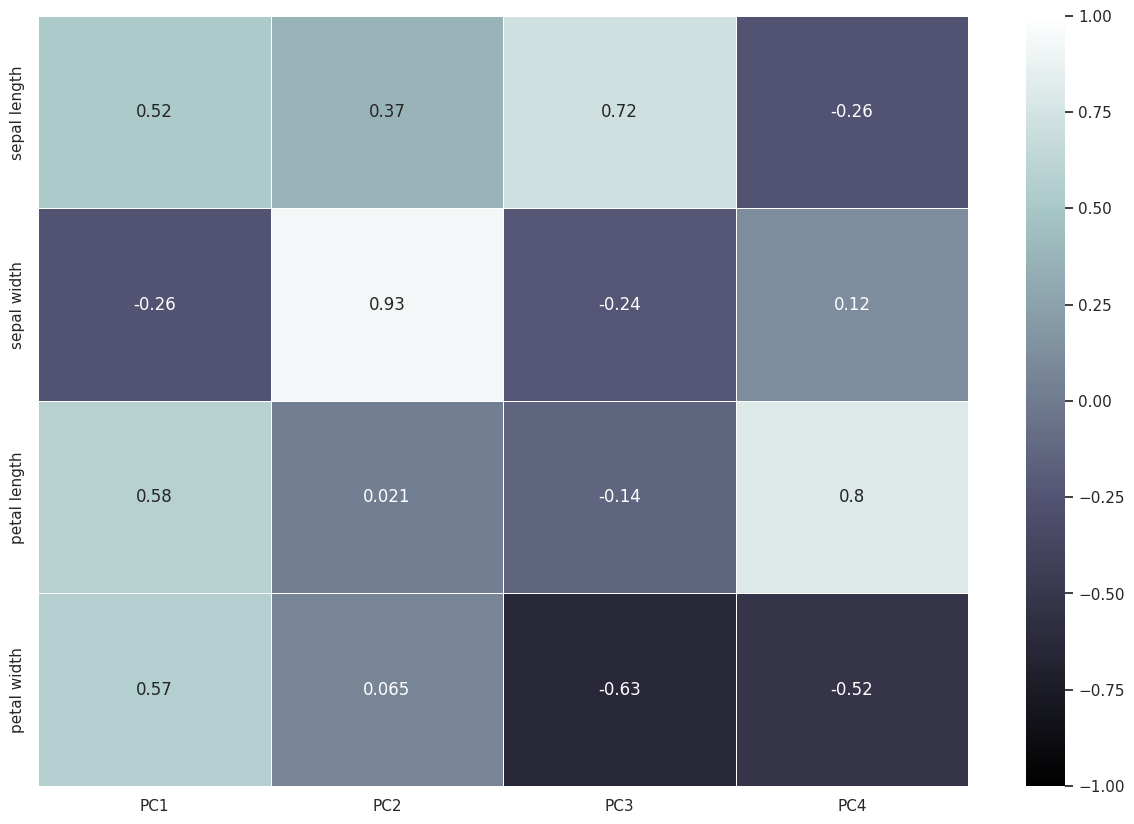

In [20]:
ax = sns.heatmap(loadings.transpose(), center=0, linewidths=0.5,
                 cmap="bone", vmin=-1, vmax=1, annot=True)

# TSNE

In [21]:
# Separate features and labels
features = data_num  # Assuming 'species' is the label column
labels = data['species']

In [22]:
from sklearn.manifold import TSNE

# Fit and transform the features using t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)


In [23]:
# Create a new DataFrame with the t-SNE results
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE-1', 'TSNE-2'])
tsne_df['species'] = labels



In [25]:
tsne_df

,TSNE-1,TSNE-2,species
0,-23.197,-2.328,Iris-setosa
1,-20.458,-1.381,Iris-setosa
2,-20.734,-2.607,Iris-setosa
3,-20.227,-2.237,Iris-setosa
4,-23.279,-2.593,Iris-setosa
...,...,...,...
145,12.639,-2.082,Iris-virginica
146,10.971,0.710,Iris-virginica
147,12.140,-1.317,Iris-virginica
148,12.657,-3.044,Iris-virginica


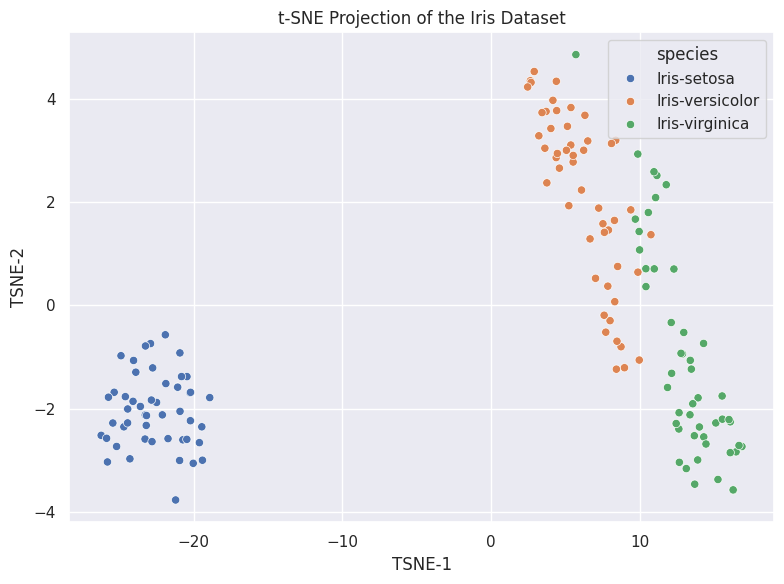

In [24]:
# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x='TSNE-1', y='TSNE-2',
    hue='species',
    palette='deep'
)
plt.title('t-SNE Projection of the Iris Dataset')
plt.tight_layout()
plt.show()

# Minisom

In [27]:
!pip install minisom


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=5f943a88b94f59c0dfba7b97db956b63270faea7218cd7fceb70fc49cf84a66b
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [28]:
from sklearn.preprocessing import MinMaxScaler

# Normalise the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(data_num)


In [29]:
from minisom import MiniSom

# Define and train the SOM
som_size = (5, 5)  # You can adjust the grid size
som = MiniSom(x=som_size[0], y=som_size[1], input_len=X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.train(X_scaled, num_iteration=1000, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.09099382941379516


In [30]:
y = labels
label_to_int = {label: idx for idx, label in enumerate(np.unique(y))}
y_numeric = [label_to_int[label] for label in y]

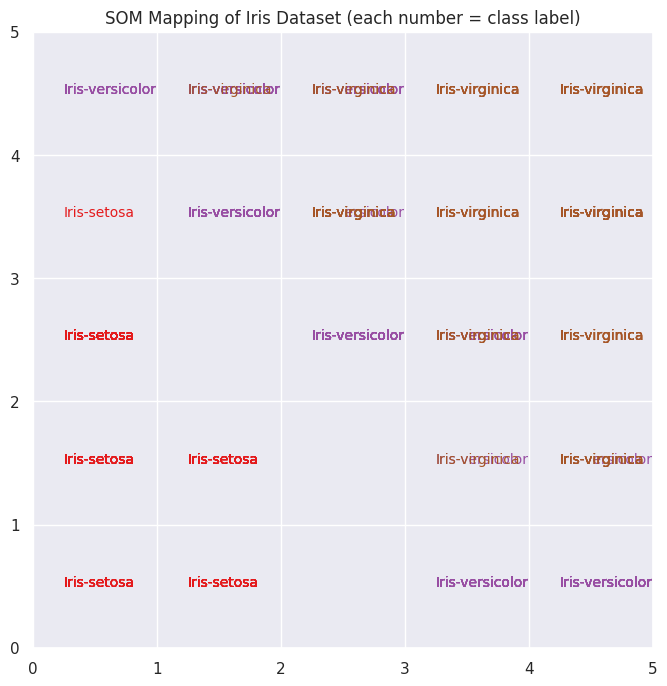

In [31]:
# Create a plot of the SOM with mapped labels
plt.figure(figsize=(8, 8))
for i, x in enumerate(X_scaled):
    w = som.winner(x)
    plt.text(w[0] + 0.25, w[1] + 0.5, str(y[i]),
             color=plt.cm.Set1(y_numeric[i] / 3),
             fontdict={'size': 10})

plt.xlim([0, som_size[0]])
plt.ylim([0, som_size[1]])
plt.title("SOM Mapping of Iris Dataset (each number = class label)")
plt.grid(True)
plt.show()